# 02 - Feature Diagnostics and Unsupervised Analysis

This notebook explores feature relationships and structure:
1. Event/censor-aware feature comparisons
2. Correlation analysis and multicollinearity hints
3. Outlier diagnostics
4. KMeans clustering and silhouette score

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATASET_DIR = Path('../dataset')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

In [14]:
train = pd.read_csv(DATASET_DIR / 'train.csv').fillna(0)
feature_cols = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]
X = train[feature_cols].copy()

print('feature count:', len(feature_cols))
print('event rate:', train['event'].mean())

feature count: 34
event rate: 0.31221719457013575


## Correlation Heatmap

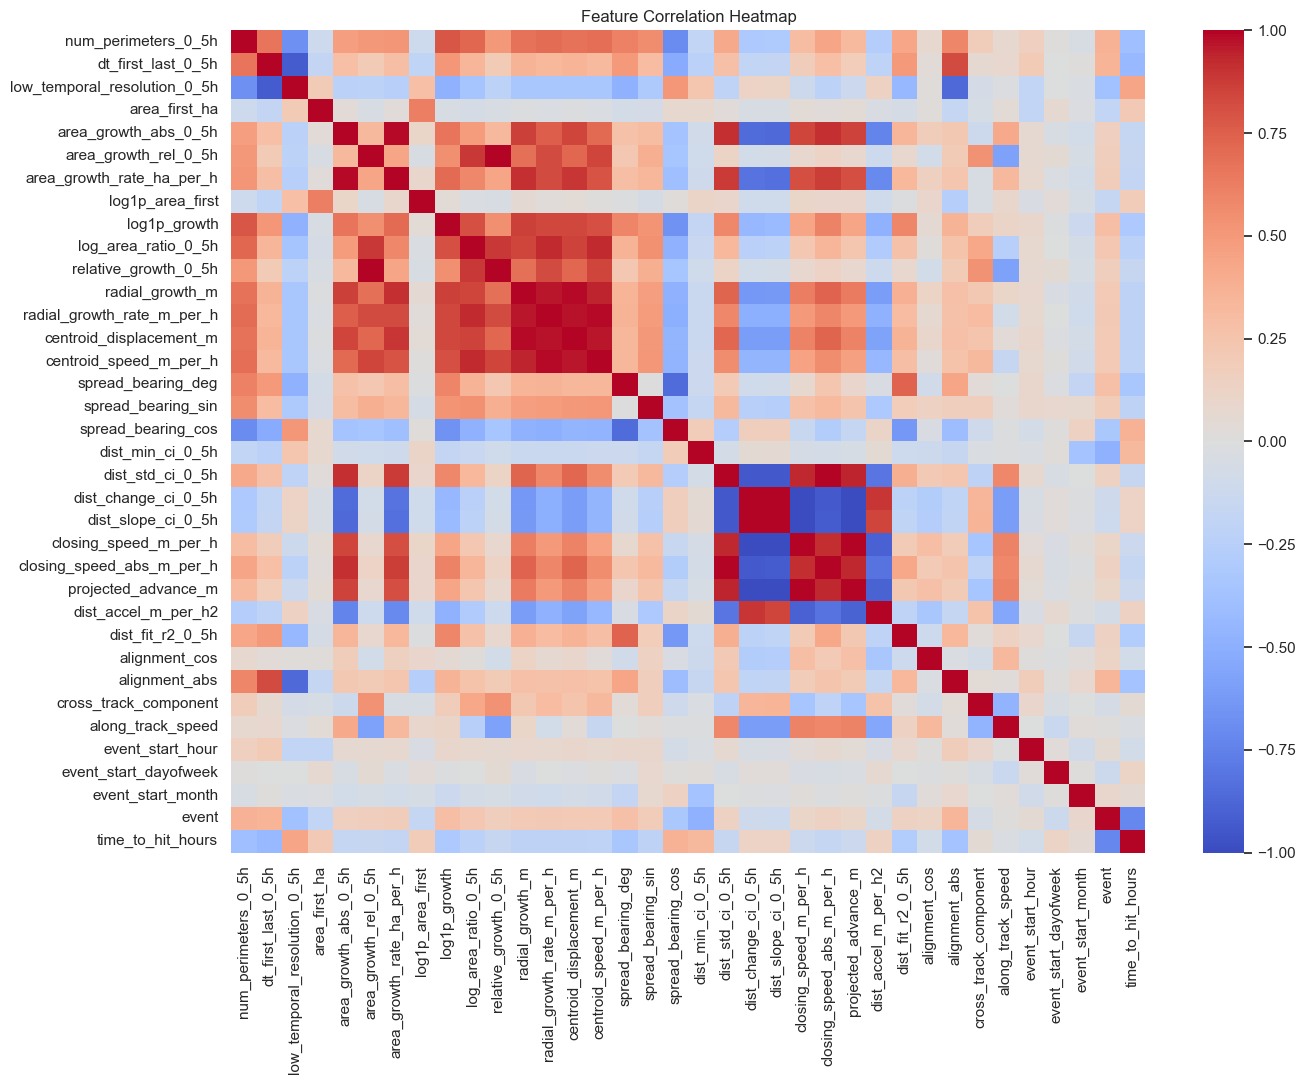

In [15]:
corr = train[feature_cols + ['event', 'time_to_hit_hours']].corr(numeric_only=True)
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_correlation_heatmap.png', dpi=150)
plt.show()

## Outlier Screening (IQR Rule)

In [16]:
outlier_report = []
for col in feature_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_count = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_report.append((col, int(out_count), out_count / len(X)))

outlier_df = pd.DataFrame(outlier_report, columns=['feature', 'outlier_count', 'outlier_ratio']).sort_values('outlier_ratio', ascending=False)
display(outlier_df.head(20))

,feature,outlier_count,outlier_ratio
6,alignment_abs,51,0.230769
1,dt_first_last_0_5h,38,0.171946
3,area_first_ha,32,0.144796
0,num_perimeters_0_5h,29,0.131222
5,dist_min_ci_0_5h,12,0.054299
9,event_start_month,2,0.009050
2,low_temporal_resolution_0_5h,0,0.000000
4,log1p_area_first,0,0.000000
7,event_start_hour,0,0.000000
8,event_start_dayofweek,0,0.000000


## KMeans and Silhouette Score

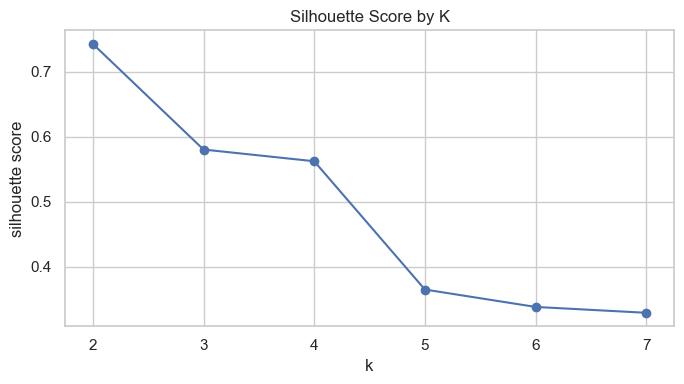

best_k by silhouette: 2


In [17]:
X_scaled = StandardScaler().fit_transform(X)
k_values = list(range(2, 8))
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_silhouette_by_k.png', dpi=150)
plt.show()

best_k = k_values[int(np.argmax(sil_scores))]
print('best_k by silhouette:', best_k)

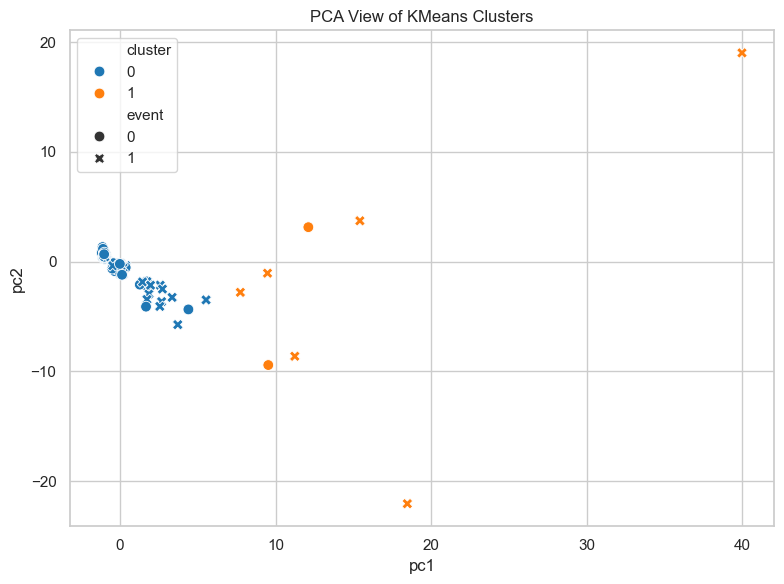

In [18]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = km.fit_predict(X_scaled)

plot_df = pd.DataFrame({
    'pc1': X_2d[:, 0],
    'pc2': X_2d[:, 1],
    'cluster': cluster_labels,
    'event': train['event'].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='cluster', style='event', palette='tab10', s=60)
plt.title('PCA View of KMeans Clusters')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_pca_kmeans_clusters.png', dpi=150)
plt.show()